<a href="https://colab.research.google.com/github/zahradhitaaisyahputri/Support-Vector-Machine-SVM-/blob/main/24523262_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Klasifikasi Data dengan Support Vector Machine (SVM) di Python**

## NIM   : 24523262
## Nama  : Zahra Dhita Aisyah Putri


### **1. Klasifikasi Dataset yang digunakan :**
https://www.kaggle.com/datasets/argonnxx/teen-mental-health

In [32]:
import pandas as pd
import os
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("argonnxx/teen-mental-health")
print("Path to dataset files:", path)

# List files and load the CSV
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)
print(f"Dataset loaded: {csv_file}")
display(df.head())

Using Colab cache for faster access to the 'teen-mental-health' dataset.
Path to dataset files: /kaggle/input/teen-mental-health
Dataset loaded: Teen_Mental_Health.csv


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score,sleep_quality,digital_wellbeing_flag
0,14,male,7.9,Facebook,7.4,2.9,3.01,1.5,low,2,2,1,0,5,Fair,At Risk
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,19,Good,Moderate
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,8,Fair,Healthy
3,15,male,7.4,YouTube,6.9,1.6,3.48,0.8,medium,1,7,9,0,17,Fair,Moderate
4,15,female,4.7,All Platforms,4.9,3.0,2.37,1.4,medium,3,5,2,0,10,Poor,Moderate


In [33]:
print(df.shape)
print(df.columns)
display(df.head())
df.info()
df.describe()

print(df['digital_wellbeing_flag'].value_counts())

print(df.columns)

(1200, 16)
Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label',
       'mental_health_risk_score', 'sleep_quality', 'digital_wellbeing_flag'],
      dtype='object')


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score,sleep_quality,digital_wellbeing_flag
0,14,male,7.9,Facebook,7.4,2.9,3.01,1.5,low,2,2,1,0,5,Fair,At Risk
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,19,Good,Moderate
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,8,Fair,Healthy
3,15,male,7.4,YouTube,6.9,1.6,3.48,0.8,medium,1,7,9,0,17,Fair,Moderate
4,15,female,4.7,All Platforms,4.9,3.0,2.37,1.4,medium,3,5,2,0,10,Poor,Moderate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
 13  mental_health_risk_score  1200 non-null   int64  
 14  sleep_qu

### **2. Preprocessing Data**

Langkah-langkah yang akan dilakukan:
1.  **Exploratory Data Analysis (EDA) Singkat**: Melihat info dataset dan missing values.
2.  **Handling Missing Values**: Menghapus atau mengisi data yang kosong.
3.  **Encoding**: Mengubah data kategorikal (teks) menjadi angka.
4.  **Scaling**: Menyamakan skala data agar SVM bekerja optimal.

In [34]:
# Cek missing value
print(df.isnull().sum())

# Hapus data kosong jika ada
df = df.dropna()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
mental_health_risk_score    0
sleep_quality               0
digital_wellbeing_flag      0
dtype: int64


In [35]:
target_col = 'digital_wellbeing_flag'

X = df.drop(columns=[target_col])
y = df[target_col]

In [36]:
# Encoding fitur kategorikal menjadi angka
X = pd.get_dummies(X, drop_first=True)

print("Data setelah encoding:")
display(X.head())

Data setelah encoding:


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score,gender_male,platform_usage_Facebook,platform_usage_Instagram,platform_usage_TikTok,platform_usage_YouTube,social_interaction_level_low,social_interaction_level_medium,sleep_quality_Good,sleep_quality_Poor
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,5,True,True,False,False,False,True,False,False,False
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,19,False,False,False,True,False,False,False,True,False
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,8,False,False,True,False,False,False,False,False,False
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,17,True,False,False,False,True,False,True,False,False
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,10,False,False,False,False,False,False,True,False,True


In [37]:
from sklearn.preprocessing import LabelEncoder

# Mengubah target menjadi angka
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Label target setelah encoding:")
print(label_encoder.classes_)
print(y[:10])

Label target setelah encoding:
['At Risk' 'Healthy' 'Moderate']
[0 2 1 2 2 0 2 2 2 1]


In [38]:
from sklearn.preprocessing import StandardScaler

# Scaling data fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data setelah scaling:")
print(X_scaled[:5])

Data setelah scaling:
[[-0.95409872  1.6578328   0.65917703  1.61882976  0.03402616  0.83427567
  -1.18736693 -1.27233544 -1.613389   -0.16284469 -2.31283468  0.97530483
   2.45306825 -0.5        -0.5        -0.38939887  1.37534224 -0.72843136
  -0.49739446 -0.81649658]
 [ 1.51979597 -1.29964891  1.07524389  1.61882976  0.39828246 -0.36859347
   0.88011599 -1.62219852  1.56744364 -0.16284469  0.46713403 -1.02532046
  -0.40765274 -0.5         2.         -0.38939887 -0.72709176 -0.72843136
   2.01047676 -0.81649658]
 [ 0.5302381  -1.59539708  0.79786598 -1.73143592  1.61247011 -1.74330107
  -1.18736693 -0.57260926 -1.25996315 -0.16284469 -1.7171271  -1.02532046
  -0.40765274  2.         -0.5        -0.38939887 -0.72709176 -0.72843136
  -0.49739446 -0.81649658]
 [-0.45931978  1.41137599  0.31245465 -0.19589748  0.84926644 -0.36859347
  -1.53194742  0.47698001  1.21401779 -0.16284469  0.06999564  0.97530483
  -0.40765274 -0.5        -0.5         2.56806088 -0.72709176  1.37281295
  -0.4973

### **3. Split Data**

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=109
)

### **4. Modeling SVM**

In [40]:
from sklearn import svm

# Membuat model SVM dengan kernel RBF
clf = svm.SVC(kernel='rbf', gamma='scale')

# Melatih model menggunakan data training
clf.fit(X_train, y_train)

# Melakukan prediksi menggunakan data testing
y_pred = clf.predict(X_test)

print("Model SVM dengan RBF Kernel berhasil dibuat dan diuji")

Model SVM dengan RBF Kernel berhasil dibuat dan diuji


Pada tahap modeling, digunakan algoritma Support Vector Machine dengan kernel RBF. Kernel RBF dipilih karena mampu menangani pola data yang tidak linear. Pada dataset Teen Mental Health, hubungan antar fitur kemungkinan tidak selalu berbentuk garis lurus, sehingga kernel RBF lebih sesuai untuk membantu model membedakan kelas target secara lebih fleksibel. Setelah model dibuat, model dilatih menggunakan data training dan diuji menggunakan data testing.

### **5. Evaluasi Model**

In [41]:
from sklearn import metrics

# Menghitung hasil evaluasi model
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, average='weighted')
recall = metrics.recall_score(y_test, y_pred, average='weighted')
f1 = metrics.f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8583333333333333
Precision: 0.8667269036595617
Recall   : 0.8583333333333333
F1 Score : 0.8529335037812359


In [42]:
average='weighted'

# Classification report
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.56      0.71        41
           1       0.90      0.78      0.83       103
           2       0.83      0.95      0.89       216

    accuracy                           0.86       360
   macro avg       0.90      0.76      0.81       360
weighted avg       0.87      0.86      0.85       360



- Analisis Overfitting atau Underfitting

Untuk mengecek apakah model overfitting atau underfitting, bandingkan akurasi data training dan testing.

In [43]:
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

# Analisis sederhana
if train_accuracy > test_accuracy + 0.10:
    print("Model kemungkinan mengalami overfitting.")
elif train_accuracy < 0.70 and test_accuracy < 0.70:
    print("Model kemungkinan mengalami underfitting.")
else:
    print("Model memiliki performa yang cukup baik dan tidak menunjukkan overfitting atau underfitting yang signifikan.")

Training Accuracy: 0.9452380952380952
Testing Accuracy : 0.8583333333333333
Model memiliki performa yang cukup baik dan tidak menunjukkan overfitting atau underfitting yang signifikan.


Pada tahap evaluasi model, digunakan beberapa metrik yaitu accuracy, precision, recall, dan F1 score. Accuracy digunakan untuk mengukur seberapa banyak prediksi model yang benar dibandingkan seluruh data testing. Precision digunakan untuk melihat seberapa tepat model dalam memprediksi suatu kelas. Recall digunakan untuk mengetahui seberapa baik model menemukan data dari kelas yang sebenarnya. Sementara itu, F1 score merupakan gabungan antara precision dan recall.

Untuk mengetahui apakah model mengalami overfitting atau underfitting, dilakukan perbandingan antara akurasi data training dan data testing. Jika akurasi training jauh lebih tinggi dibandingkan akurasi testing, maka model cenderung mengalami overfitting. Jika keduanya sama-sama rendah, maka model mengalami underfitting. Namun, jika nilai training accuracy dan testing accuracy cukup tinggi serta selisihnya tidak terlalu besar, maka model dapat dikatakan memiliki performa yang baik.

### **6. Visualisasi**

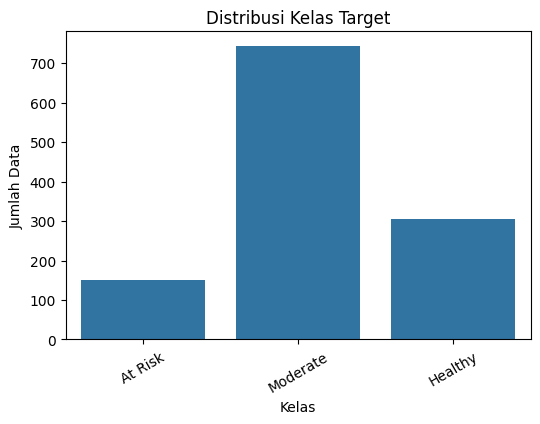

In [44]:
# VISUALISASI 1: DISTRIBUSI KELAS

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=df[target_col])
plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=30)
plt.show()

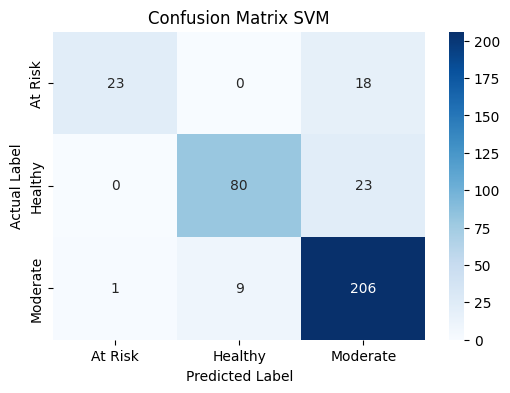

In [45]:
# VISUALISASI 2: CONFUSION MATRIX

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

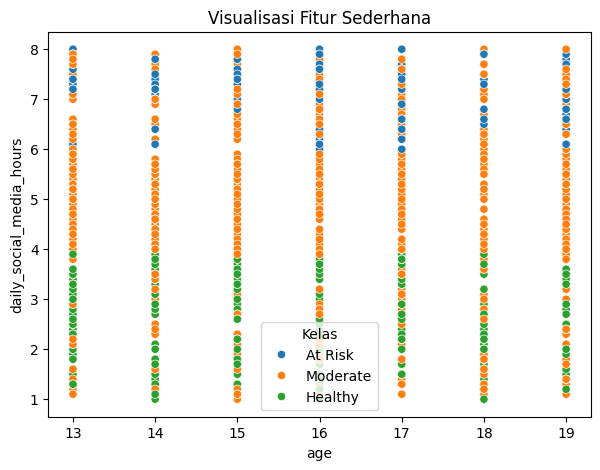

In [46]:
# VISUALISASI 3: FITUR SEDERHANA

# Ambil dua kolom numerik pertama dari dataset
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x=numeric_columns[0],
    y=numeric_columns[1],
    hue=target_col
)

plt.title("Visualisasi Fitur Sederhana")
plt.xlabel(numeric_columns[0])
plt.ylabel(numeric_columns[1])
plt.legend(title="Kelas")
plt.show()